# Analysis: 20250708

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from cdk.analysis.cytosol import platereader as pr

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data_file = "./20250708-cytation3-pure-timecourse-gfp-onepot-debug-01-pure-test-biotek-cdk.txt"
platemap_file = "./platemap.tsv"

data, platemap = pr.load_platereader_data(data_file, platemap_file)
data = data[data["Row"].isin(["B","D"])]

# Basic Analysis

## Curves
Curves of RFU over time, by named sample.

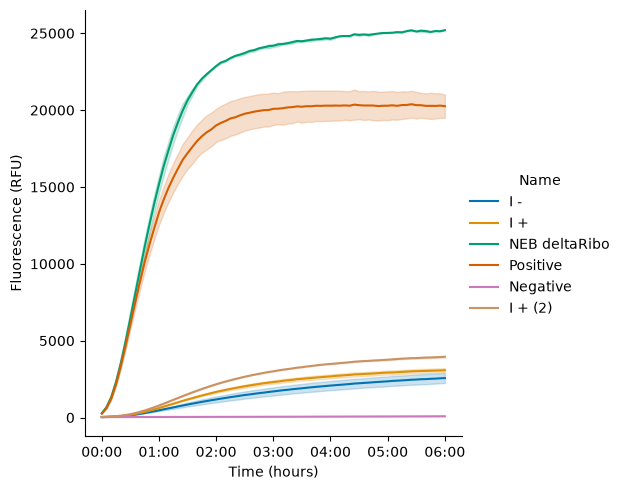

In [4]:
#| label: fig:timeseries-exp1

pr.plot_curves(data, palette="colorblind");
plt.savefig("20250708-timeseries-exp1")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

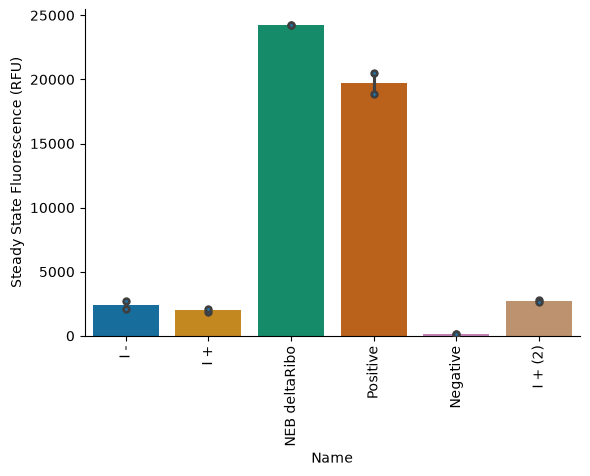

In [5]:
#| label: fig:endpoint-exp1

pr.plot_steadystate(data, palette="colorblind");
plt.savefig("20250708-endpoint-exp1")

## Kinetics
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x30c695f90>,
                                          Velocity                    \
                                              Time     Data      Max   
 Name          Read                                                    
 I +           GFP-F-G35 0 days 01:29:05.429808396  1049.73   860.66   
 I + (2)       GFP-F-G35 0 days 01:30:40.364387114  1435.89  1162.89   
 I -           GFP-F-G35 0 days 01:23:31.932670691  1282.20   533.25   
 NEB deltaRibo GFP-F-G35 0 days 00:43:28.163799042 12754.87 17850.90   
 Negative      GFP-F-G35 0 days 05:19:59.187903774    73.69    14.32   
 Positive      GFP-F-G35 0 days 00:41:29.820518411 10364.40 15263.84   
 
                                                 Lag          \
                                                Time    Data   
 Name          Read                                            
 I +           GFP-F-G35   0 days 00:15:47.351645416   77.52   
 I + (2)       GFP-F-G35   0 days 00:16:33.12795

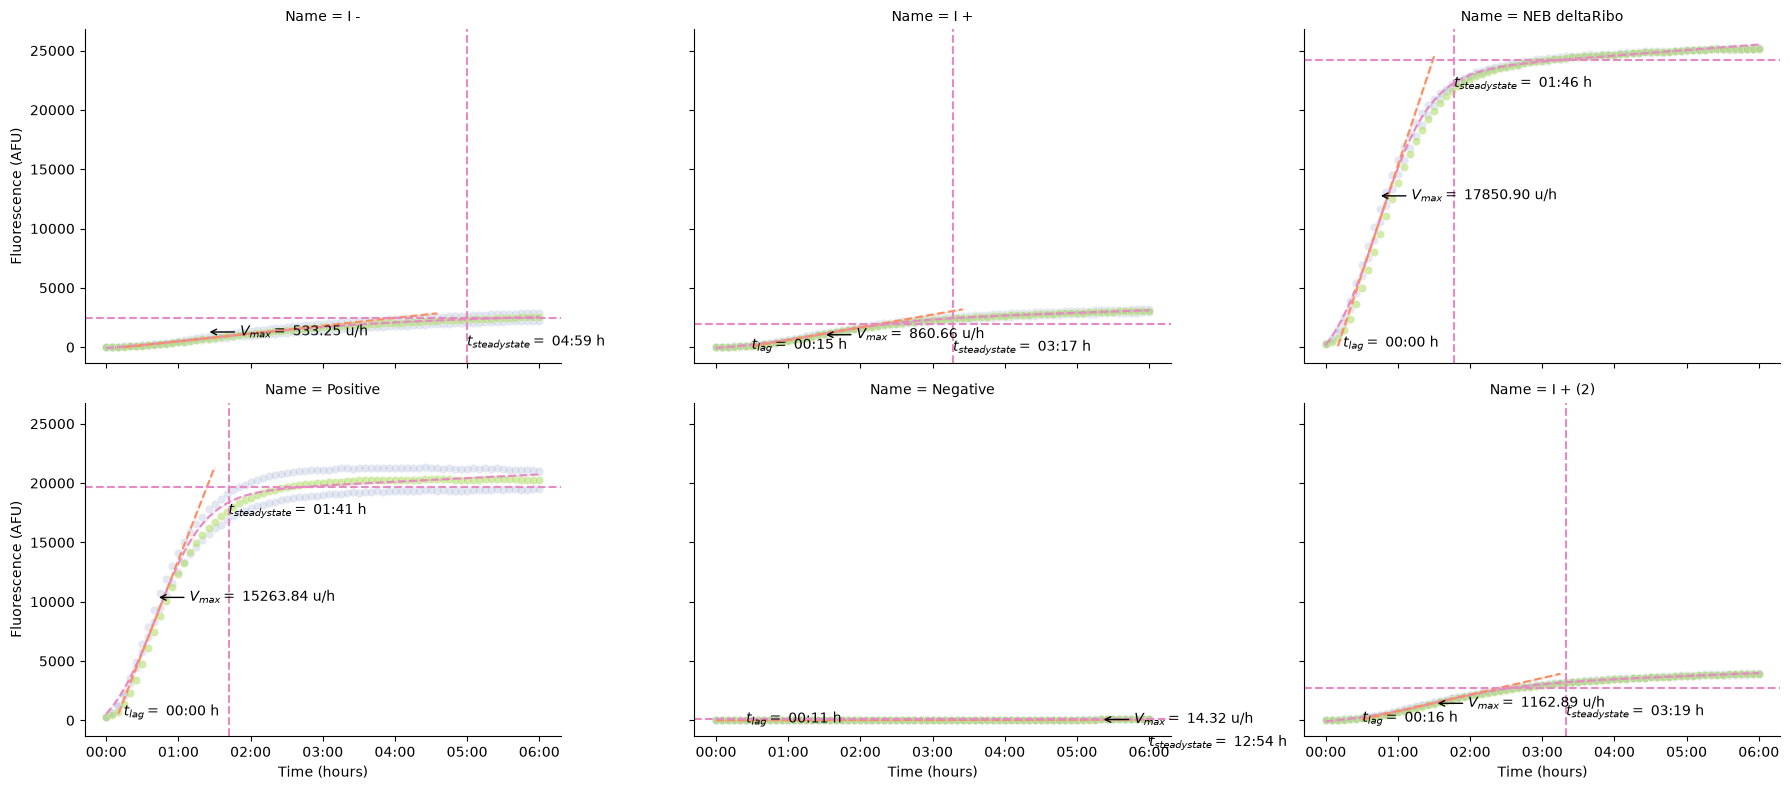

In [6]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [7]:
pr.kinetic_analysis(data)

Velocity                    \
                                                  Time     Data      Max   
Name          Read      Well                                               
I -           GFP-F-G35 B2   0 days 01:23:51.163594364  1120.31   420.36   
I +           GFP-F-G35 B4   0 days 01:26:28.097616199   991.89   794.78   
NEB deltaRibo GFP-F-G35 B6   0 days 00:40:52.742353292 12744.27 18317.25   
Positive      GFP-F-G35 B8   0 days 00:42:16.739560785 10802.59 16434.54   
Negative      GFP-F-G35 B10  0 days 05:28:22.766661570    73.97    14.17   
I + (2)       GFP-F-G35 B12  0 days 01:31:46.854326946  1467.52  1203.95   
I -           GFP-F-G35 D3   0 days 01:23:12.701747018  1444.09   646.14   
I +           GFP-F-G35 D4   0 days 01:31:42.762000593  1107.57   926.55   
NEB deltaRibo GFP-F-G35 D6   0 days 00:46:03.585244792 12765.47 17384.54   
Positive      GFP-F-G35 D8   0 days 00:40:42.901476038  9926.20 14093.13   
Negative      GFP-F-G35 D10  0 days 05:11:35.609145979    73.41    14.47   
I + (2)       GFP-F-G35 D12  0 days 01:29:33.874447282  1404.26  1121.83   

                                                     Lag          \
                                                    Time    Data   
Name          Read      Well                                       
I -           GFP-F-G35 B2   -1 days +22:43:56.759558916 -506.14   
I +           GFP-F-G35 B4     0 days 00:11:35.287177851   45.34   
NEB deltaRibo GFP-F-G35 B6   -1 days +23:59:08.034149746   98.03   
Positive      GFP-F-G35 B8     0 days 00:02:50.422550334 1032.70   
Negative      GFP-F-G35 B10    0 days 00:15:14.879920388   33.67   
I + (2)       GFP-F-G35 B12    0 days 00:18:38.742238159  119.23   
I -           GFP-F-G35 D3   -1 days +23:09:06.833318609 -527.88   
I +           GFP-F-G35 D4     0 days 00:19:59.416112982  109.70   
NEB deltaRibo GFP-F-G35 D6     0 days 00:02:00.104039322  424.85   
Positive      GFP-F-G35 D8   -1 days +23:58:27.318254801  237.80   
Negative      GFP-F-G35 D10    0 days 00:07:06.188667596   36.25   
I + (2)       GFP-F-G35 D12    0 days 00:14:27.513669991   82.44   

                                          Steady State           \
                                                  Time     Data   
Name          Read      Well                                      
I -           GFP-F-G35 B2   0 days 05:19:16.232205752  2128.60   
I +           GFP-F-G35 B4   0 days 03:16:42.500706247  1884.59   
NEB deltaRibo GFP-F-G35 B6   0 days 01:42:20.222585841 24214.12   
Positive      GFP-F-G35 B8   0 days 01:40:20.477580949 20524.93   
Negative      GFP-F-G35 B10  0 days 13:09:22.659689185   140.54   
I + (2)       GFP-F-G35 B12  0 days 03:19:27.118465140  2788.28   
I -           GFP-F-G35 D3   0 days 04:40:37.986057919  2743.77   
I +           GFP-F-G35 D4   0 days 03:17:18.231685879  2104.38   
NEB deltaRibo GFP-F-G35 D6   0 days 01:50:55.369794667 24254.39   
Positive      GFP-F-G35 D8   0 days 01:42:55.836511747 18859.78   
Negative      GFP-F-G35 D10  0 days 12:39:52.206036202   139.48   
I + (2)       GFP-F-G35 D12  0 days 03:20:08.226610285  2668.10   

                                                                            Fit  \
                                                                         params   
Name          Read      Well                                                      
I -           GFP-F-G35 B2    [2240.628718936645, 0.7504374397482767, 1.3975...   
I +           GFP-F-G35 B4    [1983.7768670489984, 1.6025603793258505, 1.441...   
NEB deltaRibo GFP-F-G35 B6    [25488.543686950845, 2.874586345286776, 0.6813...   
Positive      GFP-F-G35 B8    [21605.1890404468, 3.0427030573613414, 0.70464...   
Negative      GFP-F-G35 B10   [147.93934326881202, 0.3832256442357654, 5.472...   
I + (2)       GFP-F-G35 B12   [2935.0303101081495, 1.6407967380669668, 1.529...   
I -           GFP-F-G35 D3    [2888.1827218374538, 0.8948692194111103, 1.386...   
I +           GFP-F-G35 D4    [2215.137683572485